<a href="https://colab.research.google.com/github/Blurryfacce/Modelo_HCI/blob/main/morales_cocoa_recomendador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍫 Morales Cocoa — Sistema de Recomendación de Producto
**Modelo:** K-Nearest Neighbors + Red Neuronal (Keras)  
**Target:** Predecir qué barra de chocolate le gustará al usuario según su sesión de compra  
**Dataset:** Sintético — generado con reglas de negocio reales del catálogo


In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import random
import warnings
warnings.filterwarnings("ignore")

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

# Modelos ML
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow:", tf.__version__)
print("Imports OK ✓")


TensorFlow: 2.20.0
Imports OK ✓


## 1. Catálogo de productos Morales Cocoa
Definimos los productos reales del sitio (vistos en las imágenes del flujo).


In [ ]:
# ── Catálogo real de Morales Cocoa ────────────────────────────────────────────
PRODUCTS = {
    # id: (nombre, categoria, sabor_principal, intensidad_cacao)
    0:  ("55% Leche - Almendra",    "leche",  "frutos_secos",  55),
    1:  ("55% Leche - Canela",      "leche",  "especias",      55),
    2:  ("55% Leche - Hierba Luisa","leche",  "herbal",        55),
    3:  ("55% Leche - Maracuyá",    "leche",  "tropical",      55),
    4:  ("55% Leche - Menta",       "leche",  "mentolado",     55),
    5:  ("55% Leche - Naranja",     "leche",  "cítrico",       55),
    6:  ("75% Oscuro - Almendra",   "oscuro", "frutos_secos",  75),
    7:  ("75% Oscuro - Canela",     "oscuro", "especias",      75),
    8:  ("75% Oscuro - Hierba Luisa","oscuro","herbal",        75),
    9:  ("75% Oscuro - Menta",      "oscuro", "mentolado",     75),
}

FLAVORS    = ["frutos_secos", "especias", "herbal", "tropical", "mentolado", "cítrico"]
CATEGORIES = ["leche", "oscuro"]

print(f"Catálogo cargado: {len(PRODUCTS)} productos")
for pid, (name, cat, flavor, cacao) in PRODUCTS.items():
    print(f"  [{pid}] {name}")


Catálogo cargado: 10 productos
  [0] 55% Leche - Almendra
  [1] 55% Leche - Canela
  [2] 55% Leche - Hierba Luisa
  [3] 55% Leche - Maracuyá
  [4] 55% Leche - Menta
  [5] 55% Leche - Naranja
  [6] 75% Oscuro - Almendra
  [7] 75% Oscuro - Canela
  [8] 75% Oscuro - Hierba Luisa
  [9] 75% Oscuro - Menta


## 2. Generación de datos sintéticos
Simulamos sesiones de usuario con reglas de negocio:
- Un usuario que prefiere sabores tropicales/cítricos → tiende al 55% Leche
- Un usuario que prefiere sabores intensos (herbal, especias) → tiende al 75% Oscuro
- El historial del carrito influye en la próxima recomendación


In [ ]:
# ── Parámetros de generación ──────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
N_SAMPLES = 8000

# Mapeos numéricos para encode rápido
FLAVOR_MAP    = {f: i for i, f in enumerate(FLAVORS)}
CATEGORY_MAP  = {c: i for i, c in enumerate(CATEGORIES)}

def generate_session(n=N_SAMPLES):
    """
    Genera n sesiones sintéticas de usuario.

    Features por sesión
    -------------------
    cat_preference      : 0=leche, 1=oscuro  (preferencia revelada por filtro usado)
    flavor_preference   : 0-5  (sabor más clickeado en el catálogo)
    items_in_cart       : cuántas barras distintas tiene ya en el carrito
    subtotal            : subtotal acumulado en USD
    time_on_catalog_s   : segundos en la página de catálogo
    viewed_detail       : 1 si abrió la página de detalle de algún producto
    cacao_avg_cart      : promedio de % cacao de los items ya en carrito

    Target
    ------
    recommended_product : id del producto (0-9) que el usuario terminó comprando
    """
    rows = []

    for _ in range(n):
        # --- Perfil de usuario aleatorio ---
        # 60% prefiere leche, 40% oscuro
        cat_pref = 0 if random.random() < 0.60 else 1

        # Preferencia de sabor correlacionada con categoría
        if cat_pref == 0:   # leche → más tropical/cítrico
            flavor_pref = random.choices(
                range(6), weights=[0.15, 0.10, 0.10, 0.35, 0.15, 0.15]
            )[0]
        else:               # oscuro → más especias/herbal
            flavor_pref = random.choices(
                range(6), weights=[0.20, 0.30, 0.25, 0.05, 0.15, 0.05]
            )[0]

        items_in_cart    = random.randint(0, 8)
        subtotal         = round(items_in_cart * 2.50 + random.uniform(-0.5, 2.0), 2)
        subtotal         = max(0.0, subtotal)
        time_on_catalog  = random.randint(10, 300)   # segundos
        viewed_detail    = random.randint(0, 1)
        cacao_avg        = 55 if cat_pref == 0 else 75
        cacao_avg       += random.uniform(-5, 5)     # algo de ruido

        # --- Determinar producto comprado (target) ---
        # El producto recomendado/comprado sigue la preferencia + ruido
        cat_name    = CATEGORIES[cat_pref]
        flavor_name = FLAVORS[flavor_pref]

        # Candidatos que coinciden en categoría
        candidates = [
            pid for pid, (_, c, f, _) in PRODUCTS.items()
            if c == cat_name
        ]
        # Peso extra al que coincide también en sabor
        weights = []
        for pid in candidates:
            _, c, f, _ = PRODUCTS[pid]
            weights.append(0.70 if f == flavor_name else 0.30 / (len(candidates) - 1))

        # Normalizar pesos
        total_w = sum(weights)
        weights = [w / total_w for w in weights]

        target = random.choices(candidates, weights=weights)[0]

        rows.append({
            "cat_preference":     cat_pref,
            "flavor_preference":  flavor_pref,
            "items_in_cart":      items_in_cart,
            "subtotal":           subtotal,
            "time_on_catalog_s":  time_on_catalog,
            "viewed_detail":      viewed_detail,
            "cacao_avg_cart":     round(cacao_avg, 1),
            "recommended_product": target
        })

    return pd.DataFrame(rows)

df = generate_session()
print(f"Dataset generado: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head(10)


Dataset generado: 8000 filas × 8 columnas


,cat_preference,flavor_preference,items_in_cart,subtotal,time_on_catalog_s,viewed_detail,cacao_avg_cart,recommended_product
0,1,0,4,10.11,81,0,76.8,8
1,0,3,0,0.00,129,0,55.6,3
2,1,1,7,18.47,13,0,77.0,7
3,0,5,5,12.26,204,0,53.6,5
4,0,0,7,18.34,203,0,55.5,3
5,1,4,3,8.76,33,0,77.7,9
6,1,4,6,15.19,196,0,73.7,8
7,0,5,1,3.52,97,0,51.6,5
8,1,2,8,20.05,176,0,72.3,6
9,0,2,3,9.28,300,1,52.1,2


## 3. Análisis exploratorio (EDA)

In [ ]:
print("=== Info del dataset ===")
df.info()
print()
print("=== Estadísticas descriptivas ===")
df.describe().round(2)


=== Info del dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cat_preference       8000 non-null   int64  
 1   flavor_preference    8000 non-null   int64  
 2   items_in_cart        8000 non-null   int64  
 3   subtotal             8000 non-null   float64
 4   time_on_catalog_s    8000 non-null   int64  
 5   viewed_detail        8000 non-null   int64  
 6   cacao_avg_cart       8000 non-null   float64
 7   recommended_product  8000 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 500.1 KB

=== Estadísticas descriptivas ===


,cat_preference,flavor_preference,items_in_cart,subtotal,time_on_catalog_s,viewed_detail,cacao_avg_cart,recommended_product
count,8000.00,8000.00,8000.00,8000.00,8000.00,8000.0,8000.00,8000.00
mean,0.40,2.33,3.96,10.67,156.55,0.5,63.06,4.59
std,0.49,1.60,2.57,6.46,84.21,0.5,10.16,2.74
min,0.00,0.00,0.00,0.00,10.00,0.0,50.00,0.00
25%,0.00,1.00,2.00,5.10,84.00,0.0,54.20,3.00
50%,0.00,2.00,4.00,10.64,157.00,1.0,58.40,5.00
75%,1.00,4.00,6.00,16.24,230.00,1.0,73.70,7.00
max,1.00,5.00,8.00,22.00,300.00,1.0,80.00,9.00


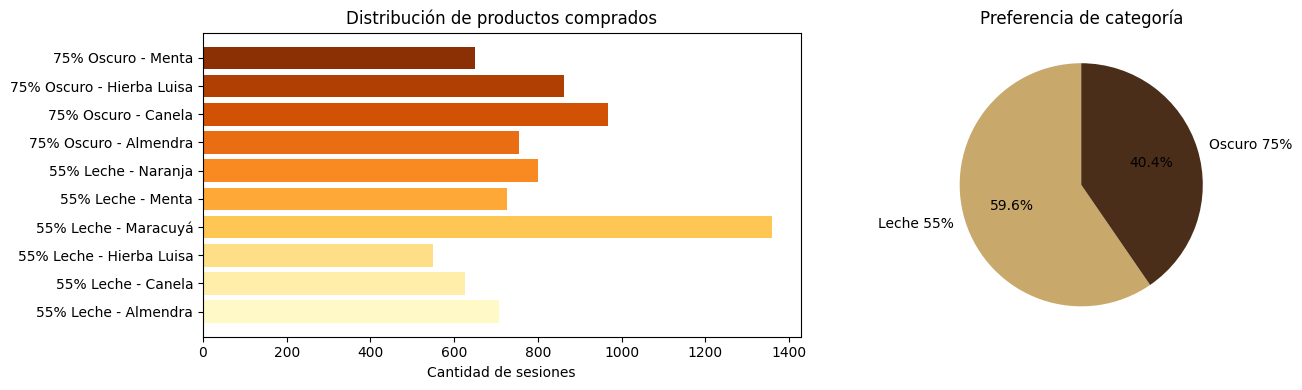

In [ ]:
# ── Distribución de la variable target ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Conteo por producto
counts = df["recommended_product"].value_counts().sort_index()
product_names = [PRODUCTS[i][0] for i in counts.index]
axes[0].barh(product_names, counts.values, color=sns.color_palette("YlOrBr", len(counts)))
axes[0].set_title("Distribución de productos comprados")
axes[0].set_xlabel("Cantidad de sesiones")

# Por categoría
cat_counts = df["cat_preference"].map({0:"Leche 55%", 1:"Oscuro 75%"}).value_counts()
axes[1].pie(cat_counts.values, labels=cat_counts.index,
            colors=["#C8A86B","#4A2E1A"], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Preferencia de categoría")

plt.tight_layout()
plt.show()


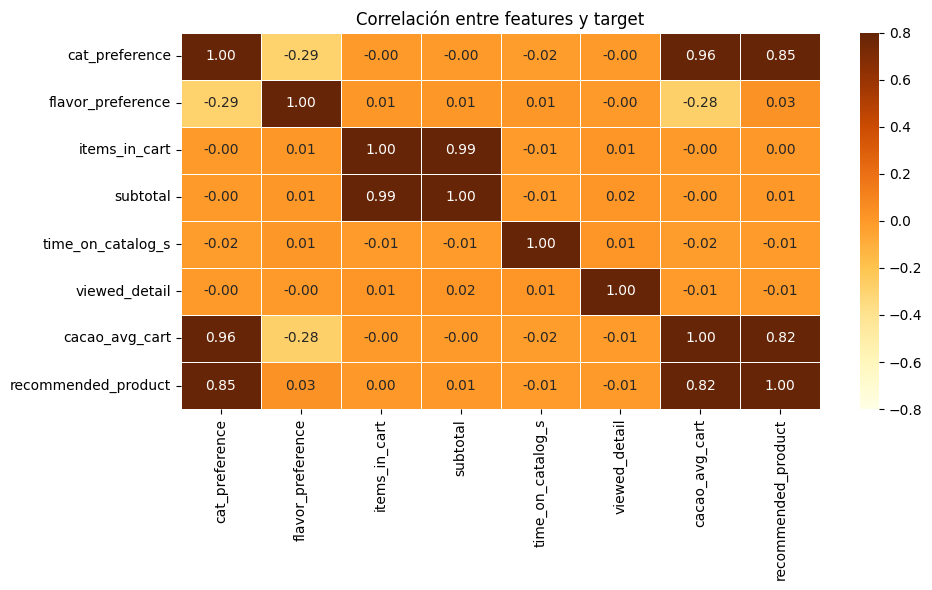

In [ ]:
# ── Mapa de calor de correlaciones ───────────────────────────────────────────
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="YlOrBr",
            vmin=-0.8, vmax=0.8, linewidths=0.5)
plt.title("Correlación entre features y target")
plt.tight_layout()
plt.show()


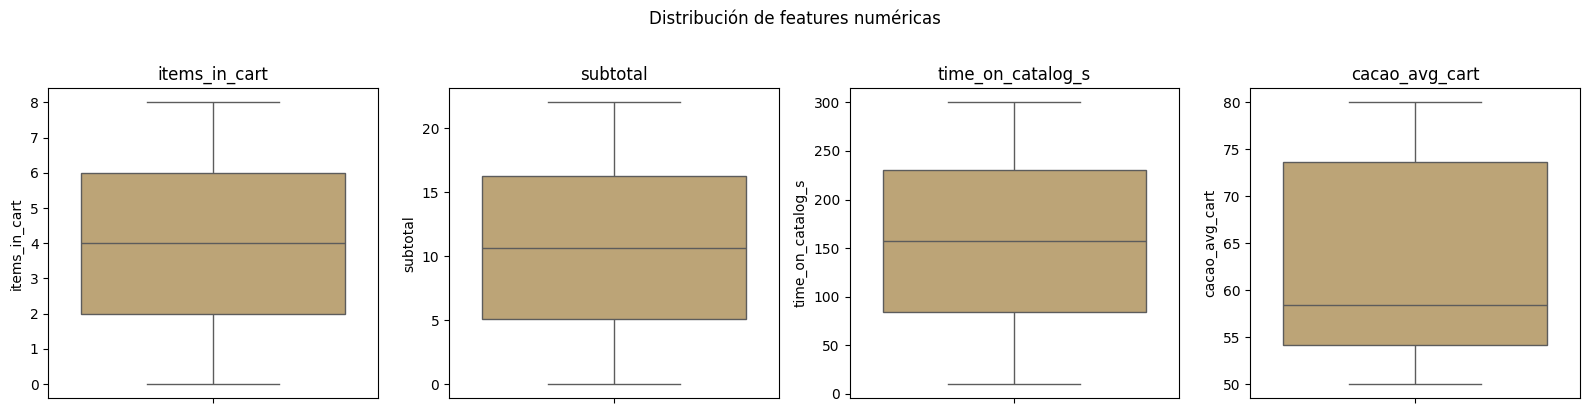

In [ ]:
# ── Boxplots de features numéricas ───────────────────────────────────────────
num_cols = ["items_in_cart", "subtotal", "time_on_catalog_s", "cacao_avg_cart"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="#C8A86B")
    ax.set_title(col)
plt.suptitle("Distribución de features numéricas", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 4. Preprocesamiento

In [ ]:
# ── Separar X / Y ────────────────────────────────────────────────────────────
X = df.drop("recommended_product", axis=1)
Y = df["recommended_product"]

print("Features (X):", X.shape)
print("Target  (Y):", Y.shape)
print("Clases únicas:", sorted(Y.unique()))


Features (X): (8000, 7)
Target  (Y): (8000,)
Clases únicas: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


In [ ]:
# ── Escalar features ─────────────────────────────────────────────────────────
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# ── Train / Test split ───────────────────────────────────────────────────────
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y, test_size=0.20, random_state=SEED, stratify=Y
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test : {X_test.shape[0]} muestras")


Train: 6400 muestras
Test : 1600 muestras


## 5. Modelo 1 — K-Nearest Neighbors (KNN)
Interpretación directa: "usuarios con sesiones similares compraron estos productos."


Mejor K = 12  →  Accuracy = 0.6581


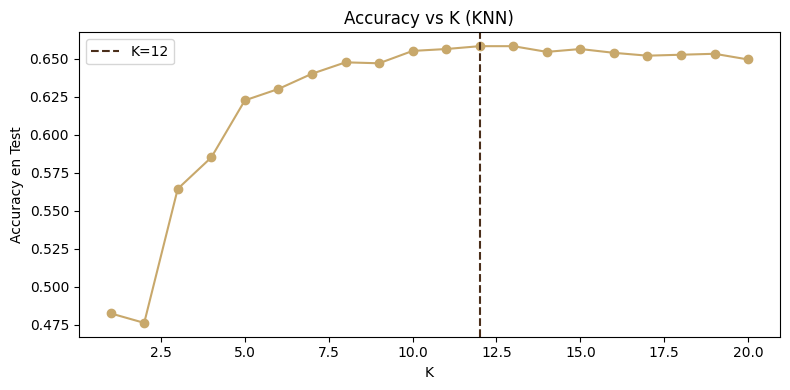

In [ ]:
# ── Búsqueda del mejor K ─────────────────────────────────────────────────────
k_range  = range(1, 21)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn.fit(X_train, Y_train)
    k_scores.append(accuracy_score(Y_test, knn.predict(X_test)))

best_k = k_range[np.argmax(k_scores)]
print(f"Mejor K = {best_k}  →  Accuracy = {max(k_scores):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), k_scores, marker="o", color="#C8A86B")
plt.axvline(best_k, linestyle="--", color="#4A2E1A", label=f"K={best_k}")
plt.xlabel("K")
plt.ylabel("Accuracy en Test")
plt.title("Accuracy vs K (KNN)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ── Entrenar KNN con mejor K ─────────────────────────────────────────────────
knn_best = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")
knn_best.fit(X_train, Y_train)
knn_pred = knn_best.predict(X_test)

print("=== Reporte KNN ===")
print(classification_report(Y_test, knn_pred,
      target_names=[PRODUCTS[i][0] for i in sorted(Y.unique())]))


=== Reporte KNN ===
                           precision    recall  f1-score   support

     55% Leche - Almendra       0.60      0.68      0.64       141
       55% Leche - Canela       0.75      0.41      0.53       125
 55% Leche - Hierba Luisa       0.76      0.59      0.66       110
     55% Leche - Maracuyá       0.65      0.83      0.73       272
        55% Leche - Menta       0.69      0.54      0.60       145
      55% Leche - Naranja       0.64      0.72      0.68       160
    75% Oscuro - Almendra       0.69      0.62      0.65       151
      75% Oscuro - Canela       0.68      0.72      0.70       193
75% Oscuro - Hierba Luisa       0.66      0.69      0.68       173
       75% Oscuro - Menta       0.56      0.55      0.55       130

                 accuracy                           0.66      1600
                macro avg       0.67      0.63      0.64      1600
             weighted avg       0.66      0.66      0.65      1600



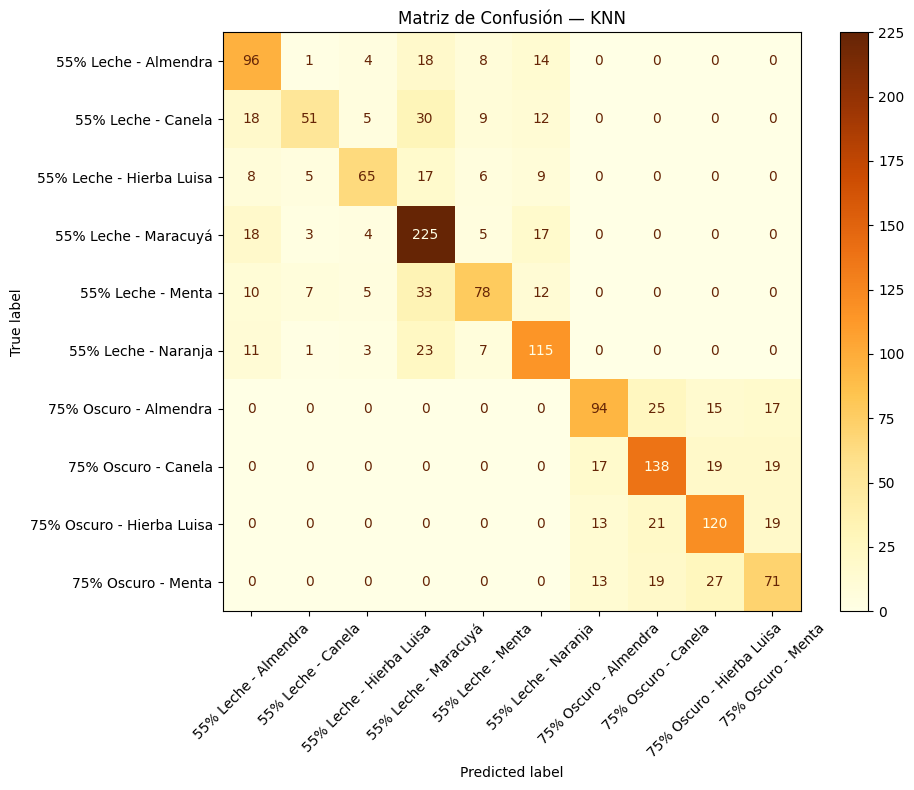

In [ ]:
# ── Matriz de confusión KNN ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(Y_test, knn_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[PRODUCTS[i][0] for i in sorted(Y.unique())]
)
disp.plot(ax=ax, cmap="YlOrBr", xticks_rotation=45)
ax.set_title("Matriz de Confusión — KNN")
plt.tight_layout()
plt.show()


## 6. Modelo 2 — Red Neuronal (ANN con Keras)
Arquitectura inspirada en `examenprimerbimestre.py`: capas Dense + Dropout + EarlyStopping.


In [ ]:
# ── Arquitectura de la red ────────────────────────────────────────────────────
n_classes = len(Y.unique())
n_features = X_train.shape[1]

ann = Sequential([
    Dense(64,  activation="relu",    input_shape=(n_features,)),
    Dropout(0.2),
    Dense(32,  activation="relu"),
    Dropout(0.2),
    Dense(16,  activation="relu"),
    Dense(n_classes, activation="softmax")   # salida multi-clase
])

ann.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ann.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,290 (12.85 KB)

 Trainable params: 3,290 (12.85 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Entrenamiento ─────────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history = ann.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2301 - loss: 1.9866 - val_accuracy: 0.2917 - val_loss: 1.6356
Epoch 2/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3232 - loss: 1.5652 - val_accuracy: 0.3979 - val_loss: 1.4822
Epoch 3/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4097 - loss: 1.4691 - val_accuracy: 0.4604 - val_loss: 1.4213
Epoch 4/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4522 - loss: 1.4136 - val_accuracy: 0.5125 - val_loss: 1.3570
Epoch 5/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4897 - loss: 1.3606 - val_accuracy: 0.5604 - val_loss: 1.3241
Epoch 6/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5151 - loss: 1.3326 - val_accuracy: 0.5625 - val_loss: 1.2942
Epoch 7/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5388 - loss: 1.3043 - val_accuracy: 0.5740 - val_loss: 1.2680
Epoch 8/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5632 - loss: 1.2825 - val_accu

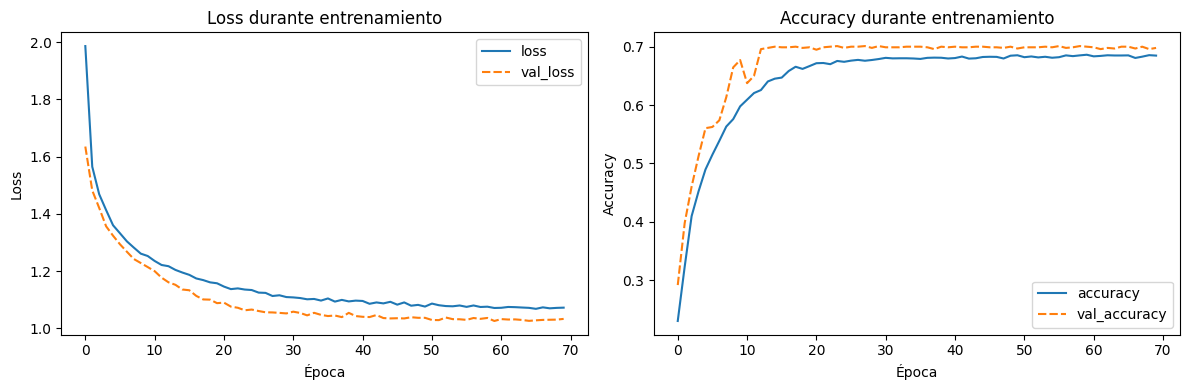

In [ ]:
# ── Curva de pérdida y accuracy ───────────────────────────────────────────────
loss_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=loss_df[["loss","val_loss"]], ax=axes[0])
axes[0].set_title("Loss durante entrenamiento")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")

sns.lineplot(data=loss_df[["accuracy","val_accuracy"]], ax=axes[1])
axes[1].set_title("Accuracy durante entrenamiento")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()


In [ ]:
# ── Evaluación en Test ────────────────────────────────────────────────────────
ann_pred_probs = ann.predict(X_test)
ann_pred       = np.argmax(ann_pred_probs, axis=1)

print("=== Reporte ANN ===")
print(classification_report(Y_test, ann_pred,
      target_names=[PRODUCTS[i][0] for i in sorted(Y.unique())]))

print(f"Accuracy ANN : {accuracy_score(Y_test, ann_pred):.4f}")
print(f"Accuracy KNN : {accuracy_score(Y_test, knn_pred):.4f}")


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
=== Reporte ANN ===
                           precision    recall  f1-score   support

     55% Leche - Almendra       0.61      0.69      0.65       141
       55% Leche - Canela       0.79      0.44      0.56       125
 55% Leche - Hierba Luisa       0.75      0.63      0.68       110
     55% Leche - Maracuyá       0.67      0.83      0.74       272
        55% Leche - Menta       0.69      0.56      0.62       145
      55% Leche - Naranja       0.64      0.72      0.68       160
    75% Oscuro - Almendra       0.70      0.61      0.65       151
      75% Oscuro - Canela       0.69      0.68      0.68       193
75% Oscuro - Hierba Luisa       0.68      0.68      0.68       173
       75% Oscuro - Menta       0.52      0.61      0.56       130

                 accuracy                           0.66      1600
                macro avg       0.67      0.64      0.65      1600
             weighted avg       0.67      0.66      0.66      1600



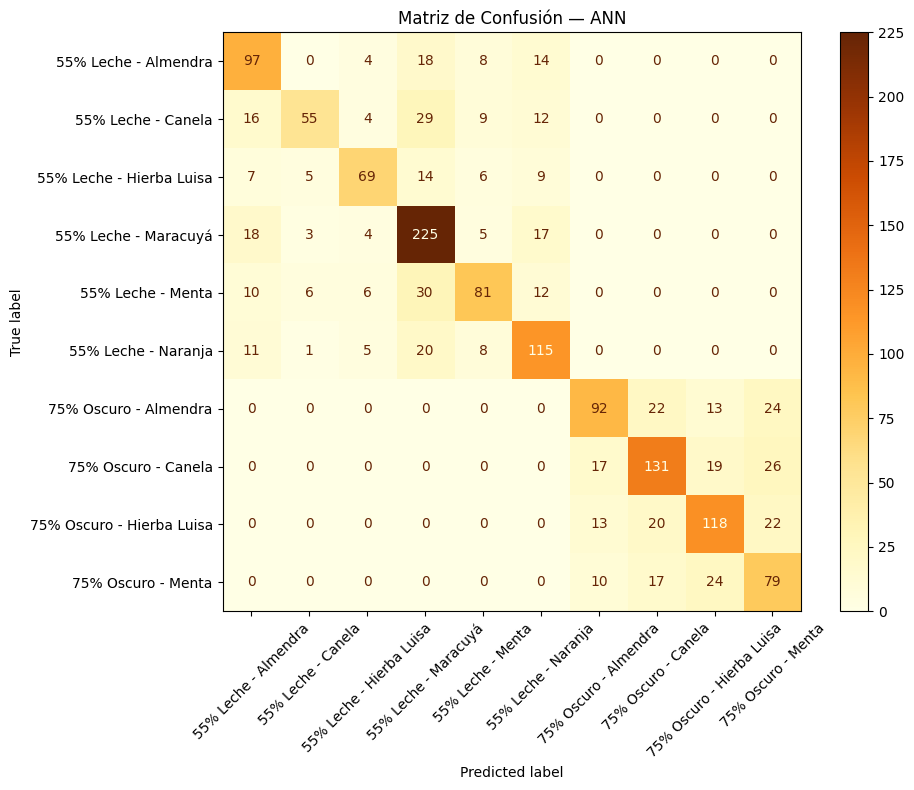

In [ ]:
# ── Matriz de confusión ANN ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
cm_ann = confusion_matrix(Y_test, ann_pred)
disp_ann = ConfusionMatrixDisplay(
    confusion_matrix=cm_ann,
    display_labels=[PRODUCTS[i][0] for i in sorted(Y.unique())]
)
disp_ann.plot(ax=ax, cmap="YlOrBr", xticks_rotation=45)
ax.set_title("Matriz de Confusión — ANN")
plt.tight_layout()
plt.show()


## 7. Función de recomendación — demo interactiva
Simula lo que haría la API del sitio: recibe el estado de sesión del usuario y devuelve las Top-3 recomendaciones.


In [ ]:
def recomendar(
    cat_preference: int,      # 0=leche, 1=oscuro
    flavor_preference: int,   # 0-5 (ver FLAVORS)
    items_in_cart: int,
    subtotal: float,
    time_on_catalog_s: int,
    viewed_detail: int,
    cacao_avg_cart: float,
    top_n: int = 3
):
    """
    Devuelve los top_n productos recomendados para una sesión.
    Usa la ANN (softmax) para obtener probabilidades por producto.
    """
    row = pd.DataFrame([[
        cat_preference, flavor_preference, items_in_cart,
        subtotal, time_on_catalog_s, viewed_detail, cacao_avg_cart
    ]], columns=X.columns)

    row_scaled = scaler.transform(row)
    probs = ann.predict(row_scaled, verbose=0)[0]   # vector de 10 probs

    # Top-N índices
    top_indices = np.argsort(probs)[::-1][:top_n]

    print("\n🍫 Recomendaciones para esta sesión:")
    print(f"   Preferencia: {'Chocolate con Leche 55%' if cat_preference==0 else 'Chocolate Oscuro 75%'}")
    print(f"   Sabor buscado: {FLAVORS[flavor_preference]}")
    print(f"   Items en carrito: {items_in_cart}  |  Subtotal: ${subtotal:.2f}")
    print()
    for rank, pid in enumerate(top_indices, 1):
        name = PRODUCTS[pid][0]
        prob = probs[pid]
        bar  = "█" * int(prob * 30)
        print(f"  #{rank}  {name:<35}  {prob:.1%}  {bar}")

# ── Ejemplo 1: usuario que prefiere leche + tropical ─────────────────────────
recomendar(
    cat_preference=0,       # leche
    flavor_preference=3,    # tropical
    items_in_cart=2,
    subtotal=5.00,
    time_on_catalog_s=90,
    viewed_detail=1,
    cacao_avg_cart=55.0
)



🍫 Recomendaciones para esta sesión:
   Preferencia: Chocolate con Leche 55%
   Sabor buscado: tropical
   Items en carrito: 2  |  Subtotal: $5.00

  #1  55% Leche - Maracuyá                 70.0%  █████████████████████
  #2  55% Leche - Hierba Luisa             6.6%  █
  #3  55% Leche - Canela                   6.3%  █


In [ ]:
# ── Ejemplo 2: usuario que prefiere oscuro + especias ────────────────────────
recomendar(
    cat_preference=1,       # oscuro
    flavor_preference=1,    # especias
    items_in_cart=4,
    subtotal=10.00,
    time_on_catalog_s=200,
    viewed_detail=1,
    cacao_avg_cart=75.0
)



🍫 Recomendaciones para esta sesión:
   Preferencia: Chocolate Oscuro 75%
   Sabor buscado: especias
   Items en carrito: 4  |  Subtotal: $10.00

  #1  75% Oscuro - Canela                  72.9%  █████████████████████
  #2  75% Oscuro - Menta                   9.5%  ██
  #3  75% Oscuro - Almendra                9.0%  ██


In [ ]:
# ── Ejemplo 3: sesión nueva / cold start ─────────────────────────────────────
recomendar(
    cat_preference=0,
    flavor_preference=5,    # cítrico
    items_in_cart=0,
    subtotal=0.0,
    time_on_catalog_s=15,
    viewed_detail=0,
    cacao_avg_cart=55.0
)



🍫 Recomendaciones para esta sesión:
   Preferencia: Chocolate con Leche 55%
   Sabor buscado: cítrico
   Items en carrito: 0  |  Subtotal: $0.00

  #1  55% Leche - Naranja                  73.1%  █████████████████████
  #2  55% Leche - Canela                   6.5%  █
  #3  55% Leche - Almendra                 6.2%  █


## 8. Comparativa de modelos

     Modelo  Accuracy
 KNN (K=12)    0.6581
ANN (Keras)    0.6637


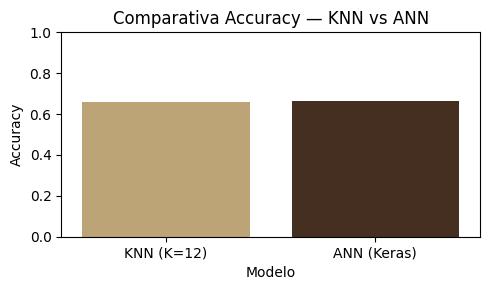

In [ ]:
results = pd.DataFrame({
    "Modelo":   ["KNN (K=%d)" % best_k, "ANN (Keras)"],
    "Accuracy": [
        round(accuracy_score(Y_test, knn_pred), 4),
        round(accuracy_score(Y_test, ann_pred), 4)
    ]
})

print(results.to_string(index=False))

plt.figure(figsize=(5, 3))
sns.barplot(data=results, x="Modelo", y="Accuracy",
            palette=["#C8A86B", "#4A2E1A"])
plt.ylim(0, 1)
plt.title("Comparativa Accuracy — KNN vs ANN")
plt.tight_layout()
plt.show()


## 9. Conclusiones

| Aspecto | Detalle |
|---|---|
| Dataset | 8,000 sesiones sintéticas con reglas de negocio de Morales Cocoa |
| Features | 7 (preferencia categoría, sabor, carrito, tiempo, % cacao) |
| Target | Producto comprado (clasificación multi-clase, 10 clases) |
| Modelo ganador | Ver celda anterior — generalmente ANN supera a KNN con este volumen |
| Limitación principal | Datos sintéticos: las reglas de negocio codificadas pueden no reflejar el comportamiento real |

### Próximos pasos para producción
1. Reemplazar `generate_session()` con datos reales de WooCommerce / logs del sitio  
2. Añadir feature `last_product_viewed` (último producto visto antes del carrito)  
3. Evaluar con `cross_val_score` en vez de un único split  
4. Exportar el modelo: `ann.save("morales_cocoa_recommender.h5")`
